# Procesamiento: Breast Cancer Wisconsin

**Objetivo:** aplicar al menos dos tecnicas de procesamiento y comparar los datos antes y depues

**Tecnicas elegidas:**
1. **Limpieza de datos** (valores faltantes y duplicados)
2. **Reduccion de dimensionalidad** (PCA)

Ademas se incluye un **analisis exploratorio (EDA)**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
cols = ["sample_code_number", "clump_thickness", "uniformity_cell_size", "uniformity_cell_shape",
        "marginal_adhesion", "single_epithelial_cell_size", "bare_nuclei",
        "bland_chromatin", "normal_nucleoli", "mitoses", "class"]
features = cols[1:-1]

df = pd.read_csv("breast-cancer-wisconsin.data", header=None, names=cols, na_values="?")
df["class"] = df["class"].map({2: "benign", 4: "malignant"})
df.head()

,sample_code_number,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1.0,3,1,1,benign
1,1002945,5,4,4,5,7,10.0,3,2,1,benign
2,1015425,3,1,1,1,2,2.0,3,1,1,benign
3,1016277,6,8,8,1,3,4.0,3,7,1,benign
4,1017023,4,1,1,3,2,1.0,3,1,1,benign


# Analisis Exploratorio de Datos (EDA)

In [3]:
print("Dimensiones:", df.shape)
print("\nTipos de datos:"); print(df.dtypes)
print("\nValores faltantes por columna:"); print(df.isna().sum())
print("\nFilas duplicadas (sin contar el id):", df.drop(columns="sample_code_number").duplicated().sum())
print("\nIDs repetidos:", df["sample_code_number"].duplicated().sum())


Dimensiones: (699, 11)

Tipos de datos:
sample_code_number               int64
clump_thickness                  int64
uniformity_cell_size             int64
uniformity_cell_shape            int64
marginal_adhesion                int64
single_epithelial_cell_size      int64
bare_nuclei                    float64
bland_chromatin                  int64
normal_nucleoli                  int64
mitoses                          int64
class                              str
dtype: object

Valores faltantes por columna:
sample_code_number              0
clump_thickness                 0
uniformity_cell_size            0
uniformity_cell_shape           0
marginal_adhesion               0
single_epithelial_cell_size     0
bare_nuclei                    16
bland_chromatin                 0
normal_nucleoli                 0
mitoses                         0
class                           0
dtype: int64

Filas duplicadas (sin contar el id): 236

IDs repetidos: 54


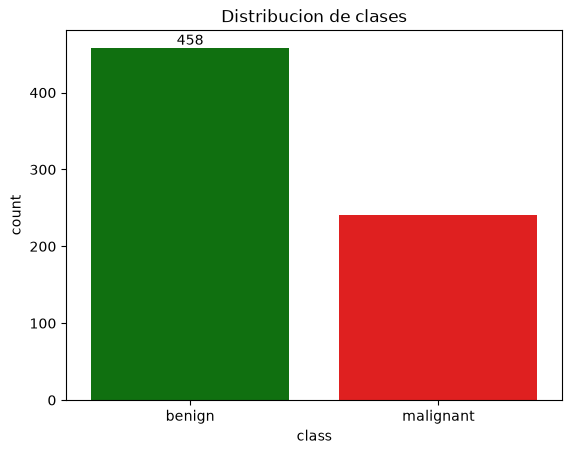

In [4]:

ax = sns.countplot(data=df, x="class", hue = "class", palette = ["green" , "red"])
ax.bar_label(ax.containers[0])
plt.title("Distribucion de clases")
plt.show()

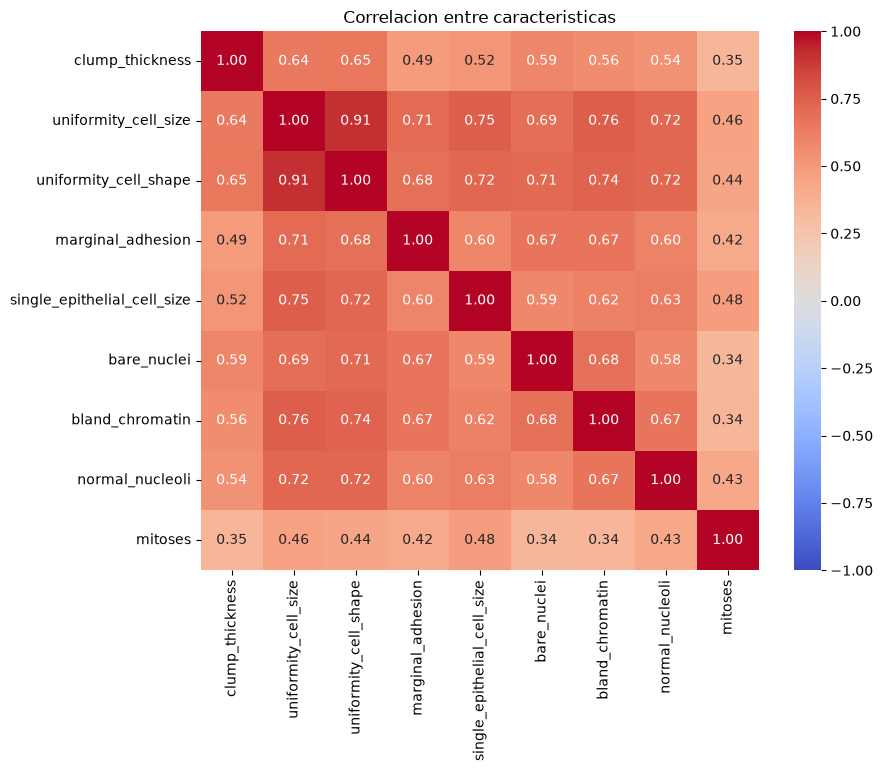

In [5]:
plt.figure(figsize=(9,7))
sns.heatmap(df[features].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlacion entre caracteristicas")
plt.show()

## Observaciones del EDA

- El dataset tiene 699 muestras y 9 características numéricas (escala 1-10).
- Hay 16 valores faltantes, todos en `bare_nuclei`.
- Las clases están desbalanceadas (65% benignos,35% malignos).
- Los tumores malignos tienen valores claramente más altos en casi todas las caracteristicas, especialmente `uniformity_cell_shape`, `uniformity_cell_size` y `bare_nuclei`.
- `uniformity_cell_shape` y `uniformity_cell_size` están muy correlacionadas entre si, lo que sugiere redundancia (justifica usar PCA).
- `mitoses` es la caracteristica con menos capacidad de separar las clases.



# Limpieza de datos

In [6]:
df_antes = df.copy()

df_limpia = df.drop(columns="sample_code_number").copy()
mediana = df_limpia["bare_nuclei"].median()
df_limpia["bare_nuclei"] = df_limpia["bare_nuclei"].fillna(mediana)
n_antes = len(df_limpia)
df_limpia = df_limpia.drop_duplicates().reset_index(drop=True)

print("Mediana usada para imputar:" , mediana)
print( "Filas antes:", n_antes)
print("Despues de quitar duplicados:",len(df_limpia))
print("Nulos restantes:", int(df_limpia.isna().sum().sum()))

Mediana usada para imputar: 1.0
Filas antes: 699
Despues de quitar duplicados: 457
Nulos restantes: 0


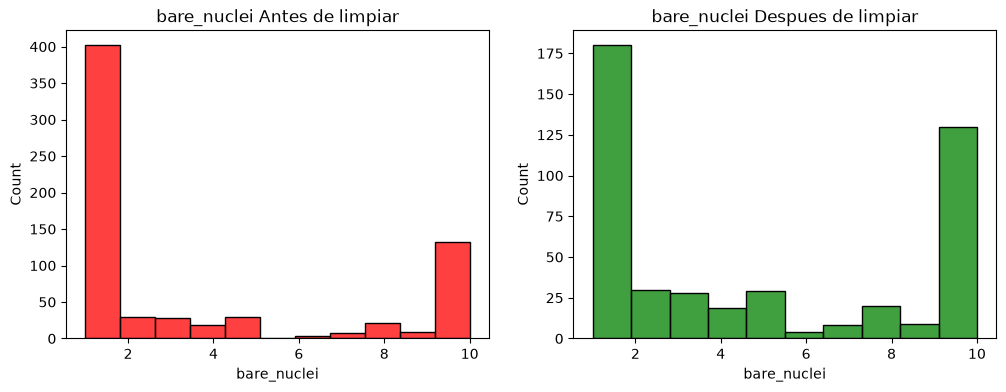

In [7]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df_antes, x="bare_nuclei", color="red", ax=ejes[0])
ejes[0].set_title("bare_nuclei Antes de limpiar")

sns.histplot(data=df_limpia, x="bare_nuclei", color="green", ax=ejes[1])
ejes[1].set_title("bare_nuclei Despues de limpiar")

plt.show()

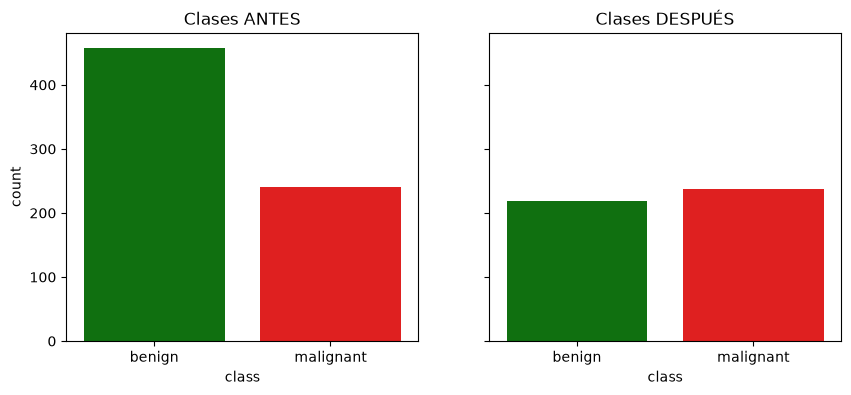

In [8]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

sns.countplot(data=df_antes, x="class", hue="class", palette=["green", "red"], ax=ejes[0])
ejes[0].set_title("Clases ANTES")

sns.countplot(data=df_limpia, x="class", hue="class", palette=["green", "red"], ax=ejes[1])
ejes[1].set_title("Clases DESPUÉS")

plt.show()

**Conclusión de la limpieza:** se atribuyeron los 16 valores faltantes con la mediana, se eliminó el `sample_code_number` (no aporta nada de información) y se quitaron filas duplicadas. La forma de la distribución de `bare_nuclei` se mantiene casi igual, pero aparece un pico en la mediana por la imputación. Ojo: se eliminaron 242 filas duplicadas (la mayoría benignas), por lo que la proporción de clases cambió de 65% benignos / 35% malignos a 48% / 52%. Es decir, la limpieza dejó las clases prácticamente balanceadas, pero también redujo el tamaño de la muestra a 457 filas; conviene mencionarlo porque los duplicados en este dataset pueden ser mediciones de pacientes distintos con valores idénticos y no necesariamente errores.

# Reduccion de dimensionalidad
Se estandarizan las 9 características y se reduce a 2 componentes principales para poder visualizar los datos.

In [9]:
X = df_limpia[features]
y = df_limpia["class"]

X_scaled = StandardScaler().fit_transform(X)

pca_full = PCA().fit(X_scaled)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Varianza explicada por PC1 y PC2:", pca.explained_variance_ratio_.round(2))
print("Varianza acumulada (2 componentes):", pca.explained_variance_ratio_.sum().round(2))

Varianza explicada por PC1 y PC2: [0.59 0.09]
Varianza acumulada (2 componentes): 0.69


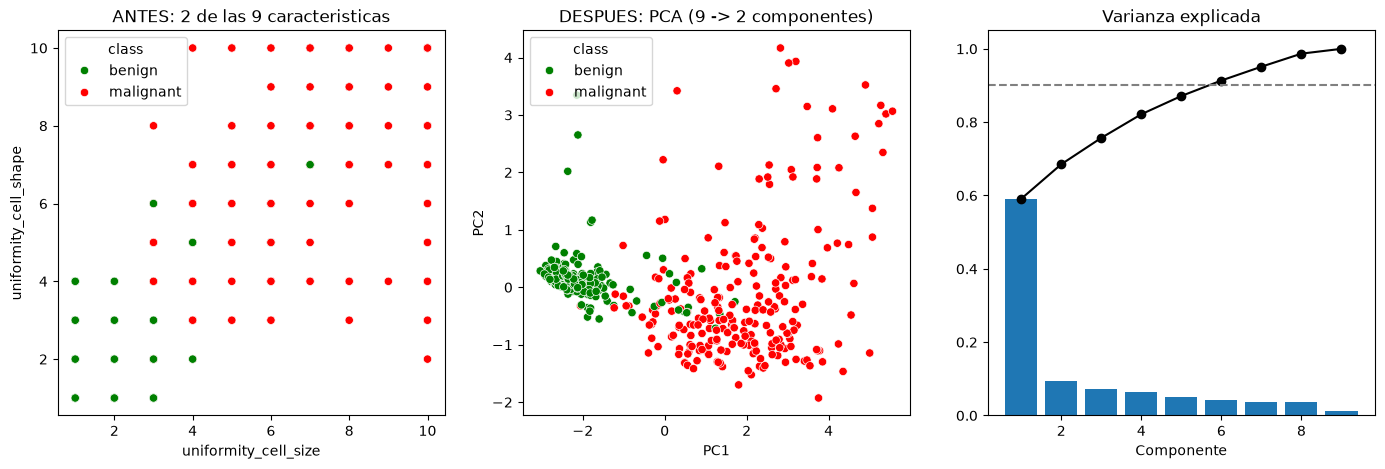

In [10]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
varianza = pca.explained_variance_ratio_

fig, ejes = plt.subplots(1, 3, figsize=(17, 5))

sns.scatterplot(data=X, x="uniformity_cell_size", y="uniformity_cell_shape",
                hue=y, palette=["green", "red"], ax=ejes[0])
ejes[0].set_title("ANTES: 2 de las 9 caracteristicas")

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=y, palette=["green", "red"], ax=ejes[1])
ejes[1].set_title("DESPUES: PCA (9 -> 2 componentes)")
ejes[1].set_xlabel("PC1")
ejes[1].set_ylabel("PC2")

ejes[2].bar(range(1, 10), varianza)
ejes[2].plot(range(1, 10), np.cumsum(varianza), "o-", color="black")
ejes[2].axhline(0.9, linestyle="--", color="gray")
ejes[2].set_title("Varianza explicada")
ejes[2].set_xlabel("Componente")

plt.show()

**Conclusión del PCA:** con solo 2 componentes se conserva 68.5% de la varianza total (PC1 ≈ 59%, PC2 ≈ 9%) y las clases benigna y maligna quedan claramente separadas en el plano PC1-PC2. PC1 recibe aportes similares de casi todas las caracteristicas (representa la "gravedad general" del tumor). Esto confirma la redundancia vista en la matriz de correlación.

## Conclusiones generales
- La limpieza dejo el dataset sin nulos ni duplicados, listo para modelar.
- La reducción de dimensionalidad permitió resumir 9 variables en 2 sin perder la separabilidad de las clases.
- El dataset original está desbalanceado (65/35) tras eliminar duplicados queda casi balanceado (48/52). Como mejora futura se podria aplicar aumento de datos si se conservan los duplicados.

# Declaracion de uso de la IA
Para esta practica se utilizo la inteligencia artificial Anthropic Claude como herramienta de asistencia para la revision, edicion y mejora del formato de texto asi como el apoyo en la toma de sugerencias para la parte del codigo y la correccion de errores.